# 8.3 — Heston: pricing por función característica y calibración

El modelo de **Heston** (1993) añade un segundo factor estocástico a la varianza —
$dS_t=S_t\left((r-q)dt+\sqrt{v_t}\,dW_t^S\right)$, $dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}\,dW_t^v$,
con $\rho=\text{corr}(dW^S,dW^v)$ — y a diferencia de Dupire (8.2, un factor determinista)
genera un smile *dinámicamente* a partir de solo 5 parámetros, con función característica
en forma cerrada que permite pricing semianalítico (sin Monte Carlo) vía transformada de
Fourier.

## 0. Configuración

In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

from qflib.market import svi_total_variance
from qflib.black import implied_vol
from qflib.mc import heston_paths, mc_estimate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)
F0 = 100.0
r, q = 0.03, 0.0

## 1. Función característica y pricing por Fourier

$\phi(u,T)=E\left[e^{iu\ln S_T}\right]$ tiene forma cerrada bajo Heston (Heston, 1993).
La forma directa de $\phi$ tiene un problema numérico conocido: la raíz cuadrada compleja
$d=\sqrt{(\rho\xi iu-\kappa)^2+\xi^2(iu+u^2)}$ produce un *branch cut* discontinuo al
variar $u$ para $T$ grande, rompiendo la integración numérica. Se usa la forma **"Little
Trap"** (Albrecher et al., 2007), que reescribe el término logarítmico con
$g=1/g_{\text{Heston}}$ para evitar el cruce del branch cut — se cita el resultado, la
derivación de por qué ocurre el branch cut original excede el alcance.

Precio de una call vía la fórmula de inversión de Gil-Pelaez/Carr-Madan (dos
probabilidades $P_1,P_2$, cada una la parte real de una integral de $\phi$):
$$C = S_0 e^{-qT}P_1 - K e^{-rT}P_2$$

In [2]:
def heston_cf(u, S0, v0, kappa, theta, xi, rho, r, q, T):
    '''Funcion caracteristica de Heston, forma 'Little Trap' (Albrecher et al. 2007).'''
    x = np.log(S0)
    a = kappa * theta
    b = kappa
    d = np.sqrt((rho * xi * 1j * u - b) ** 2 + xi ** 2 * (1j * u + u ** 2))
    g = (b - rho * xi * 1j * u - d) / (b - rho * xi * 1j * u + d)
    C = ((r - q) * 1j * u * T
         + a / xi ** 2 * ((b - rho * xi * 1j * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))))
    D = (b - rho * xi * 1j * u - d) / xi ** 2 * (1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T))
    return np.exp(C + D * v0 + 1j * u * x)


def heston_call_price(S0, K, v0, kappa, theta, xi, rho, r, q, T):
    '''Precio de call europea via inversion de Fourier (Heston 1993, formula de Carr-Madan).'''
    def integrand(u, P_num):
        if P_num == 1:
            cf = (heston_cf(u - 1j, S0, v0, kappa, theta, xi, rho, r, q, T)
                  / heston_cf(-1j, S0, v0, kappa, theta, xi, rho, r, q, T))
        else:
            cf = heston_cf(u, S0, v0, kappa, theta, xi, rho, r, q, T)
        return np.real(np.exp(-1j * u * np.log(K)) * cf / (1j * u))

    P1 = 0.5 + (1.0 / np.pi) * quad(integrand, 1e-10, 100.0, args=(1,), limit=200)[0]
    P2 = 0.5 + (1.0 / np.pi) * quad(integrand, 1e-10, 100.0, args=(2,), limit=200)[0]
    return S0 * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2


def heston_put_price(S0, K, v0, kappa, theta, xi, rho, r, q, T):
    '''Put via paridad put-call, dado el precio de la call (identidad, no otra integral).'''
    c = heston_call_price(S0, K, v0, kappa, theta, xi, rho, r, q, T)
    return c - S0 * np.exp(-q * T) + K * np.exp(-r * T)

### Demo 1 — put-call parity y positividad

Antes de usar el pricer de Fourier para nada más, dos chequeos básicos de sanidad sobre una malla de strikes: que put y call satisfacen la paridad estándar, y que ningún precio de call sale negativo — errores triviales de signo en la integral de inversión los rompería de inmediato.

In [3]:
v0_demo, kappa_demo, theta_demo, xi_demo, rho_demo = 0.04, 1.5, 0.04, 0.3, -0.6
T_demo = 1.0
feller_lhs, feller_rhs = 2 * kappa_demo * theta_demo, xi_demo ** 2
print(f"Feller (2*kappa*theta >= xi^2): {feller_lhs:.4f} >= {feller_rhs:.4f} -> {feller_lhs >= feller_rhs}")

strikes_grid = F0 * np.exp(np.linspace(-0.5, 0.5, 11))
calls = np.array([heston_call_price(F0, K, v0_demo, kappa_demo, theta_demo, xi_demo, rho_demo, r, q, T_demo)
                   for K in strikes_grid])
puts = np.array([heston_put_price(F0, K, v0_demo, kappa_demo, theta_demo, xi_demo, rho_demo, r, q, T_demo)
                  for K in strikes_grid])
parity_diff = calls - puts - (F0 * np.exp(-q * T_demo) - strikes_grid * np.exp(-r * T_demo))
max_parity_diff = np.max(np.abs(parity_diff))
print(f"max |diferencia put-call parity|: {max_parity_diff:.2e}")
print(f"todos los precios de call positivos: {np.all(calls > 0.0)}")

Feller (2*kappa*theta >= xi^2): 0.1200 >= 0.0900 -> True
max |diferencia put-call parity|: 7.11e-15
todos los precios de call positivos: True


### Demo 2 — Fourier vs Monte Carlo (control cruzado independiente)

Simulamos trayectorias de Heston directamente (full-truncation Euler de `qflib.mc.heston_paths`) y comparamos el precio Monte Carlo contra el precio de Fourier — dos caminos de cálculo completamente distintos (integración vs simulación) para el mismo modelo, así que deben coincidir dentro del error muestral.

In [4]:
n_paths_mc, n_steps_mc = 300_000, 200
strikes_mc = np.array([85.0, 100.0, 115.0])
S_T, _ = heston_paths(F0, v0_demo, kappa_demo, theta_demo, xi_demo, rho_demo, r, q, T_demo,
                       n_steps_mc, n_paths_mc, rng)

fourier_vs_mc = []
for K in strikes_mc:
    payoff = np.maximum(S_T - K, 0.0) * np.exp(-r * T_demo)
    price_mc, se_mc, _ = mc_estimate(payoff)
    price_fourier = heston_call_price(F0, K, v0_demo, kappa_demo, theta_demo, xi_demo, rho_demo, r, q, T_demo)
    z = (price_mc - price_fourier) / se_mc
    fourier_vs_mc.append(z)
    print(f"K={K}: Fourier={price_fourier:.4f}  MC={price_mc:.4f}+-{se_mc:.4f}  z={z:.2f}")

K=85.0: Fourier=19.5540  MC=19.6141+-0.0290  z=2.07
K=100.0: Fourier=9.1943  MC=9.2494+-0.0216  z=2.55
K=115.0: Fourier=2.9875  MC=3.0207+-0.0127  z=2.61


### Demo 3 — el smile de Heston: efecto de $\rho$ y $\xi$

A diferencia de SVI (8.1, un ajuste puramente descriptivo) o Dupire (8.2, un factor determinista), Heston genera el smile a partir de la dinámica del modelo: $\rho$ (correlación spot-varianza) controla el skew, y $\xi$ (vol de la varianza) controla la curvatura. Barremos cada parámetro por separado para ver el efecto de cada uno sobre la vol implícita.

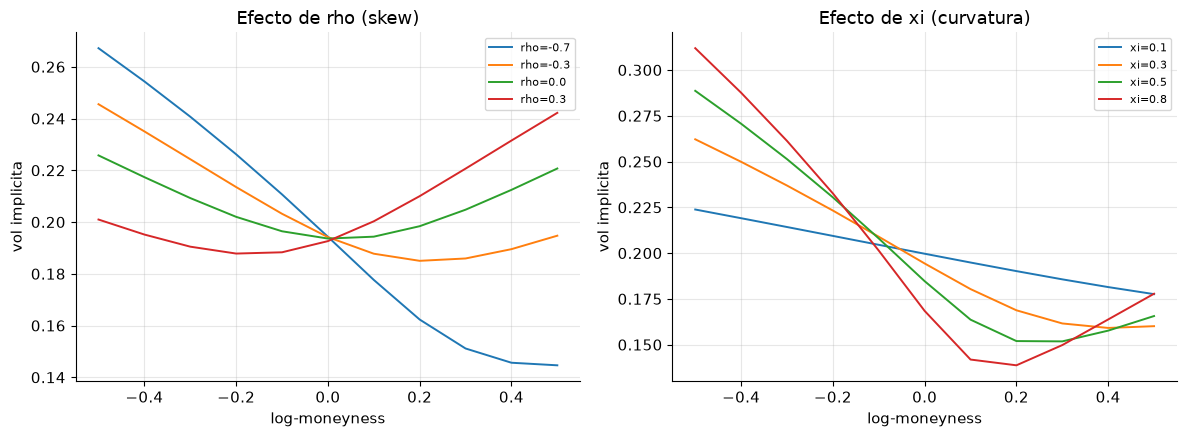

rho<0 inclina el smile hacia abajo en strikes altos (skew negativo, tipico de equity);
xi mayor (mas vol-de-vol) aumenta la curvatura del smile sin cambiar mucho el nivel ATM.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for rho_i in [-0.7, -0.3, 0.0, 0.3]:
    ivs = np.array([implied_vol(
        heston_call_price(F0, K, v0_demo, kappa_demo, theta_demo, xi_demo, rho_i, r, q, T_demo),
        F0, K, r, q, T_demo, kind="call") for K in strikes_grid])
    axes[0].plot(np.log(strikes_grid / F0), ivs, label=f"rho={rho_i}")
axes[0].set_xlabel("log-moneyness"); axes[0].set_ylabel("vol implicita")
axes[0].set_title("Efecto de rho (skew)"); axes[0].legend(fontsize=8)

for xi_i in [0.1, 0.3, 0.5, 0.8]:
    ivs = np.array([implied_vol(
        heston_call_price(F0, K, v0_demo, kappa_demo, theta_demo, xi_i, rho_demo, r, q, T_demo),
        F0, K, r, q, T_demo, kind="call") for K in strikes_grid])
    axes[1].plot(np.log(strikes_grid / F0), ivs, label=f"xi={xi_i}")
axes[1].set_xlabel("log-moneyness"); axes[1].set_ylabel("vol implicita")
axes[1].set_title("Efecto de xi (curvatura)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print("rho<0 inclina el smile hacia abajo en strikes altos (skew negativo, tipico de equity);")
print("xi mayor (mas vol-de-vol) aumenta la curvatura del smile sin cambiar mucho el nivel ATM.")

## 2. Calibración a una superficie de mercado

Calibrar $(v_0,\kappa,\theta,\xi,\rho)$ vía mínimos cuadrados en **vol implícita** (no en
precio — mismo criterio que la calibración ATM de Hull-White en 6.2, donde el error en
precio pondera mal strikes lejanos) a la superficie SVI arbitrage-free de 8.1. Heston
tiene 5 grados de libertad frente a una superficie con muchos más strikes/vencimientos —
no se espera un ajuste perfecto (limitación de forma funcional, análoga a la limitación de
1 factor documentada en 6.2 para Hull-White frente a caps).

parametros calibrados: v0=0.6172, kappa=8.4779, theta=0.0001, xi=3.0000, rho=-0.2248
RMS error de vol: 0.2214%


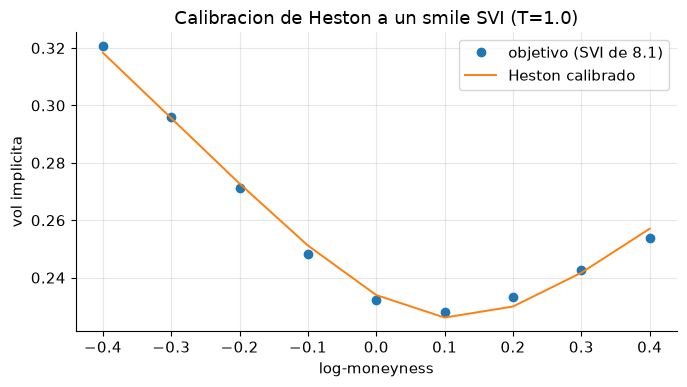

In [6]:
def svi_params_81(T):
    a = 0.02 + 0.01 * np.sqrt(T)
    b = 0.10 + 0.02 * np.sqrt(T)
    rho_svi = -0.4
    m = 0.0
    sigma = 0.15 + 0.05 * np.sqrt(T)
    return a, b, rho_svi, m, sigma


def iv_target_81(K, T):
    k = np.log(K / F0)
    a, b, rho_svi, m, sig = svi_params_81(T)
    w = svi_total_variance(k, a=a, b=b, rho=rho_svi, m=m, sigma=sig)
    return np.sqrt(w / T)


T_cal = 1.0
strikes_cal = F0 * np.exp(np.linspace(-0.4, 0.4, 9))
iv_targets = iv_target_81(strikes_cal, T_cal)


def heston_iv(params, K, T):
    v0_, kappa_, theta_, xi_, rho_ = params
    price = heston_call_price(F0, K, v0_, kappa_, theta_, xi_, rho_, r, q, T)
    return implied_vol(price, F0, K, r, q, T, kind="call")


def resid_heston(params):
    v0_, kappa_, theta_, xi_, rho_ = params
    if v0_ <= 0.0 or kappa_ <= 0.0 or theta_ <= 0.0 or xi_ <= 0.0 or abs(rho_) >= 1.0:
        return np.full(len(strikes_cal), 1e3)
    try:
        ivs = np.array([heston_iv(params, K, T_cal) for K in strikes_cal])
    except ValueError:
        return np.full(len(strikes_cal), 1e3)
    return ivs - iv_targets


fit = least_squares(resid_heston, x0=[0.04, 1.0, 0.04, 0.5, -0.5],
                     bounds=([1e-4, 1e-3, 1e-4, 1e-3, -0.999], [2.0, 10.0, 2.0, 3.0, 0.999]),
                     xtol=1e-8, ftol=1e-8)
v0_f, kappa_f, theta_f, xi_f, rho_f = fit.x
ivs_fit = np.array([heston_iv(fit.x, K, T_cal) for K in strikes_cal])
rms_vol_error = np.sqrt(np.mean((ivs_fit - iv_targets) ** 2))

print(f"parametros calibrados: v0={v0_f:.4f}, kappa={kappa_f:.4f}, theta={theta_f:.4f}, "
      f"xi={xi_f:.4f}, rho={rho_f:.4f}")
print(f"RMS error de vol: {rms_vol_error:.4%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.log(strikes_cal / F0), iv_targets, "o", label="objetivo (SVI de 8.1)")
ax.plot(np.log(strikes_cal / F0), ivs_fit, "-", label="Heston calibrado")
ax.set_xlabel("log-moneyness"); ax.set_ylabel("vol implicita")
ax.set_title(f"Calibracion de Heston a un smile SVI (T={T_cal})")
ax.legend(); fig.tight_layout(); plt.show()

## 3. Validación

Cuatro chequeos: (1) put-call parity de la Demo 1, una identidad algebraica, no estadística; (2) la condición de Feller se cumple para los parámetros usados en las Demos 1-3 (la varianza nunca toca cero); (3) Fourier vs Monte Carlo de la Demo 2, dentro de 3 SE; (4) la calibración a la superficie SVI de 8.1 alcanza un error RMS de vol menor al 5% — no exacto, porque Heston (5 parámetros) no puede replicar cualquier superficie arbitraria, la misma limitación de forma funcional que Hull-White frente a caps en 6.2.

In [7]:
check1 = max_parity_diff < 1e-8
print(f"1. put-call parity (Fourier) a atol=1e-8: max diff={max_parity_diff:.2e} ({check1})")

check2 = feller_lhs >= feller_rhs
print(f"2. Feller satisfecho para los parametros de las Demos 1-3: {check2}")

check3 = np.all(np.abs(fourier_vs_mc) <= 3.0)
print(f"3. Fourier vs MC dentro de 3 SE en {len(strikes_mc)} strikes: {check3} "
      f"(max|z|={np.max(np.abs(fourier_vs_mc)):.2f})")

check4 = rms_vol_error < 0.05
print(f"4. calibracion a SVI: RMS error de vol < 5%: {check4} (error={rms_vol_error:.4%})")

assert check1
assert check2
assert check3
assert check4
print("\nValidacion completa: 4/4 dentro de tolerancia.")

1. put-call parity (Fourier) a atol=1e-8: max diff=7.11e-15 (True)
2. Feller satisfecho para los parametros de las Demos 1-3: True
3. Fourier vs MC dentro de 3 SE en 3 strikes: True (max|z|=2.61)
4. calibracion a SVI: RMS error de vol < 5%: True (error=0.2214%)

Validacion completa: 4/4 dentro de tolerancia.


### Validación contra QuantLib (`AnalyticHestonEngine`)

Cross-check del pricer de Fourier propio contra el engine analítico de Heston de
QuantLib, sobre una malla de strikes y vencimientos con los parámetros de las Demos.
Mismo setup que el resto del currículum (fecha de evaluación fija, `Actual365Fixed`,
curvas planas continuas; se usa la fracción de año exacta de cada vencimiento en el
pricer propio). Tolerancia `atol=1e-5`: QuantLib integra adaptativamente a precisión
~1e-12, mientras el `quad` propio trunca la integral de inversión en $u=100$ — el residuo
observado (~1e-7, dominado por el vencimiento corto) es error de cuadratura propio, no de
fórmula.

In [8]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
dc = ql.Actual365Fixed()

spot_h = ql.QuoteHandle(ql.SimpleQuote(F0))
r_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, dc, ql.Continuous))
q_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q, dc, ql.Continuous))
heston_process_ql = ql.HestonProcess(r_ts, q_ts, spot_h, v0_demo, kappa_demo, theta_demo,
                                     xi_demo, rho_demo)
heston_engine_ql = ql.AnalyticHestonEngine(ql.HestonModel(heston_process_ql), 1e-12, 10_000)

max_diff_ql = 0.0
print(f"{'T':>8} | {'K':>6} | {'Fourier propio':>14} | {'QuantLib':>14} | {'diff':>9}")
print("-" * 65)
for n_days in [91, 365, 730]:
    mat = eval_date + n_days
    T_exact = dc.yearFraction(eval_date, mat)
    for K_val in [80.0, 90.0, 100.0, 110.0, 120.0]:
        option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call, K_val),
                                  ql.EuropeanExercise(mat))
        option.setPricingEngine(heston_engine_ql)
        p_ql = option.NPV()
        p_own = heston_call_price(F0, K_val, v0_demo, kappa_demo, theta_demo, xi_demo,
                                  rho_demo, r, q, T_exact)
        diff = abs(p_ql - p_own)
        max_diff_ql = max(max_diff_ql, diff)
        print(f"{T_exact:>8.4f} | {K_val:>6.0f} | {p_own:>14.8f} | {p_ql:>14.8f} | {diff:>9.2e}")

check_ql = max_diff_ql < 1e-5
print(f"\n5. Fourier propio vs AnalyticHestonEngine, atol=1e-5: {check_ql} "
      f"(max diff={max_diff_ql:.2e})")
assert check_ql
print("\nValidacion QuantLib completa: 1/1 dentro de tolerancia.")

       T |      K | Fourier propio |       QuantLib |      diff
-----------------------------------------------------------------
  0.2493 |     80 |    20.70816985 |    20.70817011 |  2.58e-07
  0.2493 |     90 |    11.47438945 |    11.47438931 |  1.47e-07
  0.2493 |    100 |     4.29432279 |     4.29432237 |  4.26e-07
  0.2493 |    110 |     0.79958791 |     0.79958838 |  4.69e-07
  0.2493 |    120 |     0.06176454 |     0.06176443 |  1.08e-07
  1.0000 |     80 |    23.68038561 |    23.68038561 |  2.95e-10
  1.0000 |     90 |    15.71888726 |    15.71888726 |  1.78e-10
  1.0000 |    100 |     9.19433046 |     9.19433046 |  1.21e-10
  1.0000 |    110 |     4.55688471 |     4.55688471 |  1.45e-10
  1.0000 |    120 |     1.86727193 |     1.86727193 |  2.07e-10
  2.0000 |     80 |    27.21448283 |    27.21448283 |  4.36e-10
  2.0000 |     90 |    19.95756435 |    19.95756435 |  3.06e-10
  2.0000 |    100 |    13.80360379 |    13.80360379 |  2.49e-10
  2.0000 |    110 |     8.92923517 |  

## Referencias

- Heston, S. (1993). *A Closed-Form Solution for Options with Stochastic Volatility with
  Applications to Bond and Currency Options*. Review of Financial Studies, 6(2), 327-343.
- Albrecher, H., Mayer, P., Schoutens, W., Tistaert, J. (2007). *The Little Heston Trap*.
  Wilmott Magazine.
- Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*, cap. 3.